# Arquitecturas Profundas
**Objetivo del bloque**: construir el mapa mental de las arquitecturas especializadas.
Cada arquitectura resuelve una limitación concreta de la anterior.
Entender esa cadena de problemas y soluciones permite elegir la arquitectura correcta.

El error típico: usar la arquitectura más conocida o más reciente sin analizar si es la adecuada.

---

**Estructura del notebook:**
1. Mapa problema-arquitectura - visión general
2. CNNs - por que la convolución supera a las capas densas para imágenes
3. RNNs y LSTMs - datos secuenciales donde el orden importa
4. GANs - el paradigma generativo adversarial
5. Mecanismo de atención - el precursor del Transformer
6. El Transformer - por que desplazó a las RNNs
7. Criterio de selección para la empresa

In [1]:
# Crear directorio de exportacion de imagenes
import os
os.makedirs('images', exist_ok=True)
print('[OK] Directorio images/ listo')

[OK] Directorio images/ listo


In [2]:
# Setup
%pip install -q numpy matplotlib
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
print("[OK] Entorno listo.")

Note: you may need to restart the kernel to use updated packages.
[OK] Entorno listo.


---
## 1. Mapa Problema-Arquitectura

Las arquitecturas no surgieron por capricho.
Cada una es la respuesta a una limitación concreta de la anterior:

| Problema a resolver | Arquitectura que lo aborda |
|---|---|
| Funciones no lineales con muchas variables | Red multicapa (MLP) |
| Patrones locales en imágenes (bordes, texturas) | Red convolucional (CNN) |
| Datos en secuencia donde el orden importa | Red recurrente (RNN) |
| Dependencias a largo plazo en secuencias | LSTM / GRU |
| Generar nuevos ejemplos realistas | Red generativa adversarial (GAN) |
| Traducir entre representaciones de distinto tamaño | Encoder-Decoder |
| Contexto completo en paralelo sin olvido secuencial | Transformer (atención) |

**La pregunta correcta antes de elegir arquitectura:**

> ¿Que limitación de los enfoques más simples me obliga a usar esta arquitectura?

Si no puedes responderla, el problema probablemente no la justifica.

> **Antes de seguir:** ¿por qué crees que elegir la arquitectura más potente o más reciente no garantiza el mejor resultado para un problema concreto?

<details>
<summary>Orientación para el instructor (desplegar tras la reflexión)</summary>

**Una respuesta madura menciona al menos uno de estos elementos:**
- Las arquitecturas están optimizadas para tipos específicos de datos (imagen, texto, tabular, secuencial); usar la equivocada añade complejidad sin beneficio
- Más parámetros no equivale a mejor generalización si los datos no lo justifican
- El coste de entrenamiento, mantenimiento e interpretabilidad crece con la complejidad
- La arquitectura correcta es la más simple que resuelve el problema

**Si nadie responde, preguntar:**
"Si tuviérais datos de ventas tabulares del ERP de la empresa, ¿por qué usaríais Gradient Boosting en lugar de un Transformer de última generación?"

**Señal de comprensión:**
El alumno puede articular al menos una razón técnica por la que la arquitectura más simple es preferible en un caso concreto, más allá de "porque es más fácil". Si vincula la elección al tipo de dato o al volumen disponible, ha captado el criterio central del bloque.

</details>

---
## 2. Redes Convolucionales (CNNs)

**El problema que resuelven**: las capas densas conectan cada neurona con todas las entradas.
Para una imagen de 224x224x3 píxeles, eso son 150.528 conexiones por neurona.
Un modelo con 1000 neuronas tiene 150 millones de parámetros solo en la primera capa.
No escala, y además no aprovecha la estructura espacial de la imagen.

**La solución**: compartición de pesos y localidad.
Un filtro (kernel) de 3x3 tiene solo 9 pesos y se aplica en todas las posiciones.
Los mismos pesos detectan el mismo patrón en cualquier parte de la imagen.

**Jerarquía de features:**
- Capa 1: detecta bordes y gradientes simples
- Capas intermedias: combina bordes en texturas y formas
- Capas profundas: reconoce objetos y conceptos complejos

**Para la empresa:**
- Reconocimiento de productos en imágenes de inventario
- Extracción de información de documentos escaneados (facturas, albaranes)
- Control de calidad visual en almacén

Hoy muchas de estas tareas se resuelven con APIs de visión multimodal (Claude, GPT-4V).
Entender CNNs permite evaluar cuando una solución propia es más eficiente que la API.

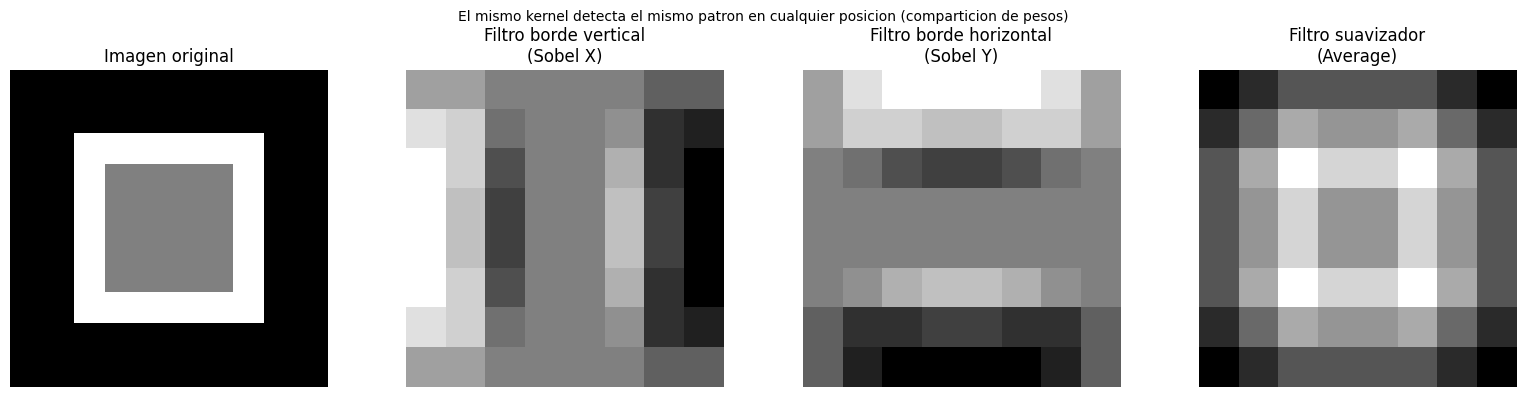

Imagen: (10, 10) -> 100 pixeles
Kernel: (3, 3) -> solo 9 parametros
Con capas densas para esta imagen: 100 x 100 = 10000 conexiones por capa
Con convolucion: solo 9 parametros para toda la imagen


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Demostracion manual de convolucion 2D
# Sin librerias de deep learning: solo numpy

def conv2d_manual(imagen, kernel):
    """Convolucion 2D valida (sin padding)."""
    h_i, w_i = imagen.shape
    h_k, w_k = kernel.shape
    h_out = h_i - h_k + 1
    w_out = w_i - w_k + 1
    output = np.zeros((h_out, w_out))
    for i in range(h_out):
        for j in range(w_out):
            output[i, j] = np.sum(imagen[i:i+h_k, j:j+w_k] * kernel)
    return output

# Crear imagen sintetica con bordes
imagen = np.zeros((10, 10))
imagen[2:8, 2:8] = 1.0  # cuadrado blanco en el centro
imagen[3:7, 3:7] = 0.5  # interior mas oscuro

# Diferentes filtros
filtro_borde_v = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])  # bordes verticales (Sobel)
filtro_borde_h = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])  # bordes horizontales
filtro_suavizar = np.ones((3, 3)) / 9                              # promediado (blur)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(imagen, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Imagen original')
axes[0].axis('off')

for ax, (filtro, nombre) in zip(axes[1:], [
    (filtro_borde_v, 'Filtro borde vertical\n(Sobel X)'),
    (filtro_borde_h, 'Filtro borde horizontal\n(Sobel Y)'),
    (filtro_suavizar, 'Filtro suavizador\n(Average)'),
]):
    resultado = conv2d_manual(imagen, filtro)
    ax.imshow(resultado, cmap='gray')
    ax.set_title(nombre)
    ax.axis('off')

plt.suptitle('El mismo kernel detecta el mismo patron en cualquier posicion (comparticion de pesos)', fontsize=10)
plt.tight_layout()
plt.savefig('images/B05_fig01.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


print(f"Imagen: {imagen.shape} -> 100 pixeles")
print(f"Kernel: {filtro_borde_v.shape} -> solo 9 parametros")
print(f"Con capas densas para esta imagen: {10*10} x {10*10} = {10*10*10*10} conexiones por capa")
print(f"Con convolucion: solo 9 parametros para toda la imagen")

---
## 3. RNNs y LSTMs - Secuencias con Memoria

**El problema que resuelven**: los datos con orden importa (texto, series temporales de ventas,
logs de eventos, audio). Las CNNs y las redes densas procesan cada entrada de forma independiente.
Una RNN mantiene un estado interno que actúa como memoria del contexto anterior.

```
h_t = f(W_xh * x_t + W_hh * h_{t-1} + b)
```

**El problema de las RNNs básicas**: el desvanecimiento del gradiente en el tiempo.
Al hacer backpropagation a través de 100 pasos temporales, el gradiente se multiplica
100 veces por la matriz de pesos. Si los valores propios son < 1, el gradiente se hace cero.
Resultado: no puede aprender dependencias de más de 10-20 pasos.

**LSTM (Long Short-Term Memory)**:
Tres compuertas (forget, input, output) controlan el flujo de información.
El estado de celda `c_t` se actualiza mediante sumas, no multiplicaciones de matrices.
Esto crea un camino de gradiente directo a través del tiempo.

**Para la empresa:** predicción de inventario con series temporales de ventas,
detección de patrones en logs de actividad de clientes (precursores de churn).

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Demostracion del problema del gradiente en RNNs basicas
# y como LSTMs lo mitigan

np.random.seed(42)

# Simular el gradiente a traves del tiempo para una RNN basica
# Si W_hh tiene valor propio < 1: gradiente se desvanece
# Si W_hh tiene valor propio > 1: gradiente explota

n_pasos = 50
pasos = np.arange(1, n_pasos + 1)

# RNN basica con diferentes valores de W
w_desvanece = 0.9   # valor propio < 1: desvanecimiento
w_estable = 1.0     # valor propio = 1: estable (raro en la practica)
w_explota = 1.05    # valor propio > 1: explosion

grad_desvanece = w_desvanece ** pasos
grad_estable = w_estable ** pasos
grad_explota = np.clip(w_explota ** pasos, 0, 200)

# LSTM: el gradiente fluye por el estado de celda (aproximacion simplificada)
# El forget gate controla el flujo: si forget ~ 1, el gradiente se preserva
grad_lstm = np.ones(n_pasos) * 0.95 + 0.05 * np.random.randn(n_pasos)
grad_lstm = np.clip(np.cumsum(grad_lstm * 0.02), 0.3, 1.2)[::-1]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(pasos, grad_desvanece, 'r-', label=f'RNN basica (W={w_desvanece}): gradiente se desvanece', linewidth=2)
ax.plot(pasos, grad_explota, 'orange', label=f'RNN basica (W={w_explota}): gradiente explota', linewidth=2)
ax.plot(pasos, [1.0] * n_pasos, 'g--', label='Gradiente ideal (constante)', linewidth=1, alpha=0.7)
ax.plot(pasos, grad_lstm, 'b-', label='LSTM: gradiente estable por compuertas', linewidth=2)
ax.set_xlabel('Pasos temporales hacia atras (backpropagation through time)')
ax.set_ylabel('Magnitud del gradiente')
ax.set_title('El problema del gradiente en secuencias largas: RNN vs LSTM')
ax.axhline(y=0.01, color='gray', linestyle=':', alpha=0.5, label='Umbral de vanishing')
ax.legend(fontsize=8)
ax.set_ylim(-0.1, 2.5)
ax.set_xlim(1, n_pasos)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/B05_fig02.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


print("Conclusion:")
print("  RNN basica: no puede aprender dependencias a mas de ~20 pasos temporales.")
print("  LSTM: las compuertas crean un camino de gradiente estable a largo plazo.")
print("  Transformer (siguiente seccion): elimina la recurrencia completamente.")

Conclusion:
  RNN basica: no puede aprender dependencias a mas de ~20 pasos temporales.
  LSTM: las compuertas crean un camino de gradiente estable a largo plazo.
  Transformer (siguiente seccion): elimina la recurrencia completamente.


---
## 4. GANs - Dos Redes en Competencia

**El problema que resuelven**: generar datos nuevos (imágenes, audio, texto)
que sean indistinguibles de los reales.

**La idea**: dos redes en juego de suma cero:
- **Generador (G)**: recibe ruido aleatorio, produce datos sintéticos
- **Discriminador (D)**: distingue real de generado

El generador mejora para engañar al discriminador.
El discriminador mejora para detectar al generador.
Si converge: G produce muestras indistinguibles de las reales.

**Por que importa para el contexto actual:**
Las GANs demostraron que las máquinas pueden **crear** contenido nuevo, no solo clasificar.
Esa capacidad generativa es el precursor conceptual de los modelos de difusión
y de los LLMs que la empresa usa hoy en producción.

**Limitación clave de las GANs:**
El entrenamiento es notoriamente inestable (mode collapse: el generador aprende
a producir siempre el mismo tipo de muestra que engaña al discriminador).
Los modelos de difusión resolvieron este problema con un enfoque diferente.

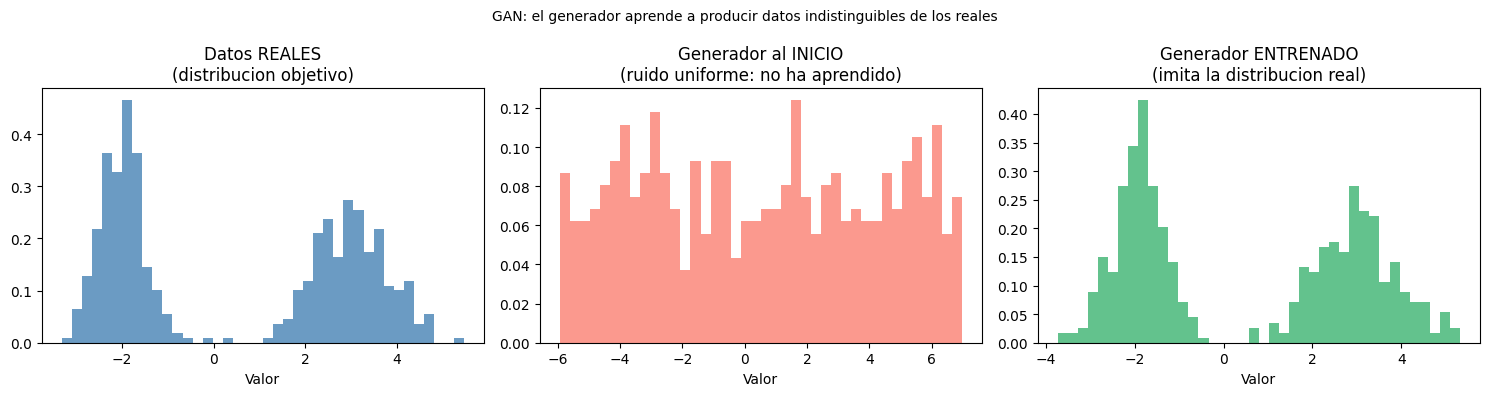

La misma logica se aplica a:
 - Imagenes (StyleGAN: rostros fotorrealistas)
 - Datos sinteticos de entrenamiento (cuando hay pocos datos reales)
 - Aumento de datos para entrenamiento de clasificadores


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Simulacion conceptual de una GAN en 1D
# El generador aprende a imitar una distribucion objetivo

np.random.seed(42)
n_muestras = 500

# Distribucion real: mezcla de dos gaussianas (datos de negocio no triviales)
datos_reales = np.concatenate([
    np.random.normal(loc=-2, scale=0.5, size=n_muestras // 2),
    np.random.normal(loc=3, scale=0.8, size=n_muestras // 2)
])

# Generador al inicio (no ha aprendido nada): distribucion uniforme
gen_inicio = np.random.uniform(-6, 7, n_muestras)

# Generador entrenado (simulado): ha aprendido a imitar la mezcla
gen_entrenado = np.concatenate([
    np.random.normal(loc=-2, scale=0.6, size=n_muestras // 2),
    np.random.normal(loc=3, scale=0.9, size=n_muestras // 2)
])

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

axes[0].hist(datos_reales, bins=40, color='steelblue', alpha=0.8, density=True)
axes[0].set_title('Datos REALES\n(distribucion objetivo)')
axes[0].set_xlabel('Valor')

axes[1].hist(gen_inicio, bins=40, color='salmon', alpha=0.8, density=True)
axes[1].set_title('Generador al INICIO\n(ruido uniforme: no ha aprendido)')
axes[1].set_xlabel('Valor')

axes[2].hist(gen_entrenado, bins=40, color='mediumseagreen', alpha=0.8, density=True)
axes[2].set_title('Generador ENTRENADO\n(imita la distribucion real)')
axes[2].set_xlabel('Valor')

plt.suptitle('GAN: el generador aprende a producir datos indistinguibles de los reales', fontsize=10)
plt.tight_layout()
plt.savefig('images/B05_fig03.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


print("La misma logica se aplica a:")
print(" - Imagenes (StyleGAN: rostros fotorrealistas)")
print(" - Datos sinteticos de entrenamiento (cuando hay pocos datos reales)")
print(" - Aumento de datos para entrenamiento de clasificadores")

---
## 5. Mecanismo de Atención - el precursor del Transformer

**El problema que resuelve**: el cuello de botella del Encoder-Decoder clásico.
Toda la información de la secuencia de entrada debía comprimirse en un único vector.
Para secuencias largas, esto implica pérdida inevitable de información.

**La solución (Bahdanau, 2014)**: en lugar de un único vector de contexto,
el decoder puede "mirar atrás" a todas las posiciones del encoder en cada paso.

```
Para generar "cat" (traducción de "gato"):
 - Alta atención sobre "gato" (la traducción directa)
 - Baja atención sobre "el", "esta", "en"
```

**La pregunta que hicieron Vaswani et al. en 2017:**
> Si la atención es lo único que realmente importa, ¿para que necesitamos las RNNs?

La respuesta fue el Transformer.

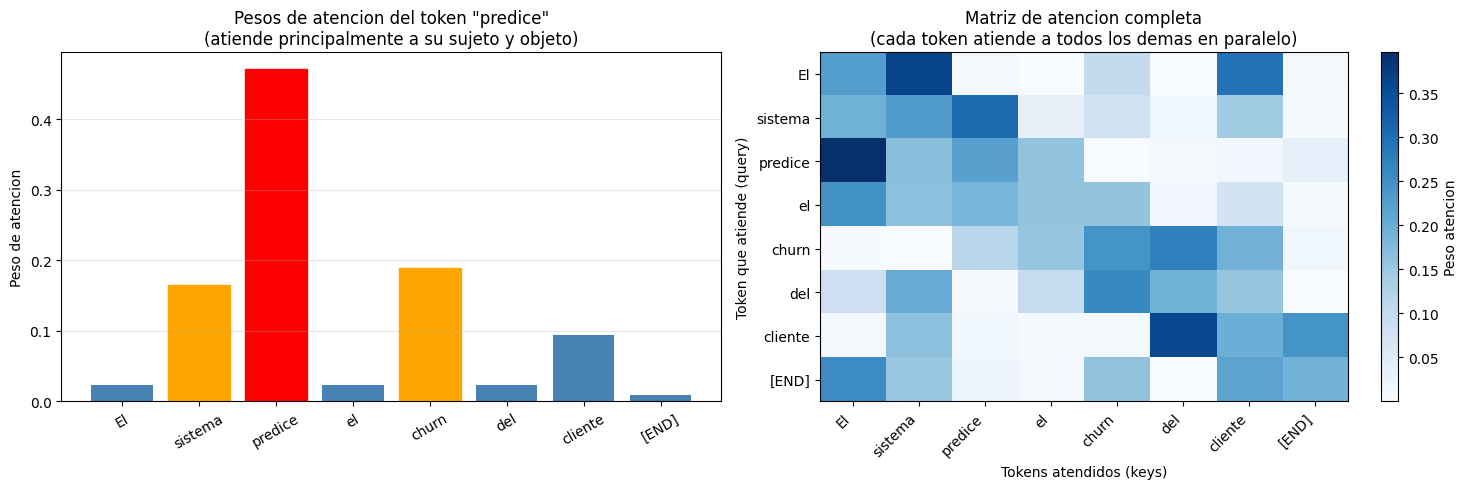

La clave del mecanismo de atencion:
  Cada token puede atender a CUALQUIER otro token, independientemente de la distancia.
  En una RNN, 'cliente' (pos 6) solo conoce 'churn' (pos 4) despues de 2 pasos.
  En un Transformer, lo conoce directamente en un solo paso.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Visualizacion del mecanismo de atencion
# Simplificacion: como un token decide a cuales otros tokens atender

# Frase ejemplo
tokens = ["El", "sistema", "predice", "el", "churn", "del", "cliente", "[END]"]
n = len(tokens)

# Pesos de atencion simulados para el token "predice" (posicion 2)
# Alta atencion sobre "sistema" (sujeto) y "churn" (objeto)
atencion_predice = np.array([0.05, 0.35, 1.0, 0.05, 0.40, 0.05, 0.20, 0.02])
atencion_predice = atencion_predice / atencion_predice.sum()

# Pesos de atencion para el token "cliente" (posicion 6)
atencion_cliente = np.array([0.03, 0.08, 0.05, 0.03, 0.25, 0.10, 1.0, 0.02])
atencion_cliente = atencion_cliente / atencion_cliente.sum()

# Matriz de atencion completa (simulada)
np.random.seed(42)
atencion_matrix = np.random.dirichlet(np.ones(n) * 0.5, size=n)
# Forzar estructura diagonal (cada token atiende principalmente a si mismo y vecinos)
for i in range(n):
    atencion_matrix[i, max(0, i-1):min(n, i+2)] += 0.3
    atencion_matrix[i] /= atencion_matrix[i].sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Atencion de un token especifico
ax = axes[0]
bars = ax.bar(tokens, atencion_predice, color=['steelblue']*n)
bars[2].set_color('red')   # el token "predice" se atiende a si mismo
bars[1].set_color('orange')  # alta atencion sobre "sistema"
bars[4].set_color('orange')  # alta atencion sobre "churn"
ax.set_title('Pesos de atencion del token "predice"\n(atiende principalmente a su sujeto y objeto)')
ax.set_ylabel('Peso de atencion')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.3, axis='y')

# Matriz de atencion completa
ax2 = axes[1]
im = ax2.imshow(atencion_matrix, cmap='Blues', aspect='auto')
ax2.set_xticks(range(n))
ax2.set_yticks(range(n))
ax2.set_xticklabels(tokens, rotation=45, ha='right')
ax2.set_yticklabels(tokens)
ax2.set_xlabel('Tokens atendidos (keys)')
ax2.set_ylabel('Token que atiende (query)')
ax2.set_title('Matriz de atencion completa\n(cada token atiende a todos los demas en paralelo)')
plt.colorbar(im, ax=ax2, label='Peso atencion')

plt.tight_layout()
plt.savefig('images/B05_fig04.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


print("La clave del mecanismo de atencion:")
print("  Cada token puede atender a CUALQUIER otro token, independientemente de la distancia.")
print("  En una RNN, 'cliente' (pos 6) solo conoce 'churn' (pos 4) despues de 2 pasos.")
print("  En un Transformer, lo conoce directamente en un solo paso.")

---
## 6. El Transformer - Atención es Todo lo que Necesitas

Paper: "Attention Is All You Need" (Vaswani et al., 2017)
Probablemente el artículo más influyente en IA de la última década.

**Por que supera a las RNNs:**

| Aspecto | RNN/LSTM | Transformer |
|---|---|---|
| Procesamiento | Secuencial (token a token) | Paralelo (todos a la vez) |
| Dependencias largas | Limitadas por desvanecimiento | Directas en un solo paso |
| Entrenamiento | Lento (sin paralelizar) | Rápido (GPU lo paraleliza nativamente) |
| Escala | Limitada | Escala a billones de parámetros |

**La operación core: Self-Attention**
```
Attention(Q, K, V) = softmax(Q * K^T / sqrt(d_k)) * V
```

- Query (Q): "que estoy buscando"
- Key (K): "que ofrezco como información"
- Value (V): "que información transfiero si me seleccionan"

**Para un desarrollador .NET**: es como un LINQ JOIN
donde la condición de unión es la similaridad semántica, no la igualdad exacta.

**Las tres familias de Transformers:**
- **Encoder-only (BERT)**: comprensión bidireccional. Para clasificación, extracción, búsqueda.
- **Decoder-only (GPT, Claude, Llama)**: generación autoregresiva. Para texto, código, respuestas.
- **Encoder-decoder (T5, BART)**: transformación. Para traducción, resumen.

In [7]:
import numpy as np

# Implementacion minima de Self-Attention desde cero
# Para entender exactamente que ocurre matematicamente

np.random.seed(42)

def self_attention(Q, K, V):
    """
    Scaled Dot-Product Attention.
    Q, K, V: matrices (seq_len, d_k)
    """
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)  # similaridad entre todos los pares
    # Softmax: convertir scores en pesos de atencion (probabilidades)
    scores_exp = np.exp(scores - scores.max(axis=-1, keepdims=True))
    attention_weights = scores_exp / scores_exp.sum(axis=-1, keepdims=True)
    # Combinar values ponderados por los pesos de atencion
    output = attention_weights @ V
    return output, attention_weights

# Secuencia de 5 tokens, dimension d_k = 4
seq_len = 5
d_k = 4

# Embeddings de los tokens (normalmente aprendidos, aqui aleatorios)
embeddings = np.random.randn(seq_len, d_k)

# Proyecciones Q, K, V (normalmente matrices de pesos aprendidas)
W_Q = np.random.randn(d_k, d_k)
W_K = np.random.randn(d_k, d_k)
W_V = np.random.randn(d_k, d_k)

Q = embeddings @ W_Q
K = embeddings @ W_K
V = embeddings @ W_V

output, pesos_atencion = self_attention(Q, K, V)

tokens_ejemplo = ["El", "modelo", "predice", "el", "churn"]

print(f"Secuencia de entrada: {tokens_ejemplo}")
print(f"Dimension de embedding: {d_k}")
print()
print("Pesos de atencion (cada fila = cuanto atiende ese token a cada otro):")
print(f"{'':>10}", end="")
for t in tokens_ejemplo:
    print(f"{t:>10}", end="")
print()
for i, (t, fila) in enumerate(zip(tokens_ejemplo, pesos_atencion)):
    print(f"{t:>10}", end="")
    for w in fila:
        print(f"{w:>10.3f}", end="")
    print()

print()
print("Cada fila es una distribucion de probabilidad (suma = 1.0)")
print(f"Suma fila 0: {pesos_atencion[0].sum():.4f}")
print()
print("Output: representacion enriquecida de cada token con el contexto de todos los demas.")
print(f"Shape output: {output.shape} (misma que entrada: {embeddings.shape})")

Secuencia de entrada: ['El', 'modelo', 'predice', 'el', 'churn']
Dimension de embedding: 4

Pesos de atencion (cada fila = cuanto atiende ese token a cada otro):
                  El    modelo   predice        el     churn
        El     0.924     0.045     0.008     0.022     0.001
    modelo     0.252     0.746     0.001     0.001     0.000
   predice     0.043     0.232     0.177     0.115     0.432
        el     0.000     0.000     0.069     0.112     0.819
     churn     0.001     0.036     0.067     0.022     0.874

Cada fila es una distribucion de probabilidad (suma = 1.0)
Suma fila 0: 1.0000

Output: representacion enriquecida de cada token con el contexto de todos los demas.
Shape output: (5, 4) (misma que entrada: (5, 4))


---
## 7. Criterio de Selección para la empresa

Con el mapa completo de arquitecturas, la pregunta práctica es:
**¿que arquitectura uso para cada tipo de problema en la empresa?**

| Tipo de dato | Tipo de problema | Arquitectura recomendada |
|---|---|---|
| Tabular (ERP, CRM) | Clasificación, regresión | Gradient Boosting (sin redes) |
| Serie temporal (ventas, logs) | Predicción, anomalías | LSTM o Transformer temporal |
| Texto (tickets, emails, RFPs) | Clasificación, extracción | BERT o LLM via API |
| Texto (generación, respuesta) | QA, redacción, resumen | LLM via API (Claude, GPT-4) |
| Imagen (facturas escaneadas) | OCR, clasificación visual | CNN o visión API (Claude Vision) |
| Texto + estructura (RFP) | Extracción estructurada | LLM con function calling |

**Principio de Occam para arquitecturas:**
La arquitectura más simple que resuelve el problema es la correcta.
Añadir complejidad solo cuando la más simple demuestra ser insuficiente.

Para la empresa en 2025, la mayoría de los casos de uso se resuelven con:
1. **Gradient Boosting** (sklearn/XGBoost) para datos tabulares del ERP
2. **LLM via API** (Claude, Azure OpenAI) para texto
3. **APIs de visión** para imágenes y documentos escaneados

Entrenar arquitecturas propias solo se justifica cuando el caso de uso
es suficientemente específico o el volumen hace que la API sea costosa.

In [8]:
# Herramienta de decision: dado un problema, que arquitectura usar?

def recomendar_arquitectura(tipo_dato, tipo_problema, volumen_datos):
    """
    Recomienda una arquitectura para un problema dado.
    tipo_dato: 'tabular', 'texto', 'serie_temporal', 'imagen'
    tipo_problema: 'clasificacion', 'regresion', 'generacion', 'extraccion', 'clustering'
    volumen_datos: 'pequeño' (<10k), 'moderado' (10k-1M), 'grande' (>1M)
    """
    print(f"Problema: {tipo_dato} + {tipo_problema} + {volumen_datos}")
    print("-" * 55)

    if tipo_dato == 'tabular':
        if tipo_problema == 'clustering':
            rec = "K-Means / DBSCAN"
            just = "No supervisado: no hay etiquetas, se buscan grupos naturales"
        elif tipo_problema in ['clasificacion', 'regresion']:
            if volumen_datos == 'pequeño':
                rec = "Regresion logistica / Arbol de decision"
                just = "Pocos datos: modelos simples interpretables y con baja varianza"
            else:
                rec = "Gradient Boosting (XGBoost / LightGBM)"
                just = "Datos tabulares: Gradient Boosting supera a las redes en este dominio"
        else:
            rec = "Revisar definicion del problema"
            just = "La generacion sobre datos tabulares es inusual"

    elif tipo_dato == 'texto':
        if tipo_problema in ['clasificacion', 'extraccion']:
            rec = "LLM via API (Claude / Azure OpenAI)"
            just = "Para clasificacion y extraccion de texto, los LLMs son state-of-the-art sin entrenamiento"
        elif tipo_problema == 'generacion':
            rec = "LLM via API (Claude / Azure OpenAI)"
            just = "Generacion de texto: LLM es la unica opcion viable en 2025"
        else:
            rec = "LLM via API"
            just = "Cualquier tarea sobre texto: empieza con un LLM"

    elif tipo_dato == 'serie_temporal':
        if volumen_datos == 'pequeño':
            rec = "ARIMA / Prophet (estadistico clasico)"
            just = "Pocos datos: modelos estadisticos interpretables superan a las redes"
        elif tipo_problema == 'anomalias':
            rec = "Isolation Forest / LSTM Autoencoder"
            just = "Anomalias en series: aprender el patron normal y detectar desviaciones"
        else:
            rec = "Gradient Boosting con features temporales / LSTM"
            just = "Series temporales con patron complejo: GB con lag features suele ser suficiente"

    elif tipo_dato == 'imagen':
        rec = "API de vision (Claude Vision / Azure Computer Vision)"
        just = "Para imagenes de negocio: la API es mas rapida y precisa que entrenar una CNN propia"

    else:
        rec = "Definir mejor el tipo de dato"
        just = "El tipo de dato determina la arquitectura"

    print(f"Recomendacion: {rec}")
    print(f"Justificacion: {just}")
    print()

# Casos de uso de la empresa
print("=" * 55)
print("HERRAMIENTA DE DECISION DE ARQUITECTURA")
print("Casos de uso de la empresa")
print("=" * 55)
print()

recomendar_arquitectura('tabular', 'clasificacion', 'moderado')   # churn, urgencia tickets
recomendar_arquitectura('tabular', 'regresion', 'moderado')       # prediccion de inventario
recomendar_arquitectura('texto', 'extraccion', 'moderado')        # procesamiento de RFPs
recomendar_arquitectura('texto', 'generacion', 'pequeño')         # generacion de propuestas
recomendar_arquitectura('serie_temporal', 'anomalias', 'moderado') # deteccion anomalias stock
recomendar_arquitectura('imagen', 'clasificacion', 'moderado')    # facturas escaneadas

HERRAMIENTA DE DECISION DE ARQUITECTURA
Casos de uso de la empresa

Problema: tabular + clasificacion + moderado
-------------------------------------------------------
Recomendacion: Gradient Boosting (XGBoost / LightGBM)
Justificacion: Datos tabulares: Gradient Boosting supera a las redes en este dominio

Problema: tabular + regresion + moderado
-------------------------------------------------------
Recomendacion: Gradient Boosting (XGBoost / LightGBM)
Justificacion: Datos tabulares: Gradient Boosting supera a las redes en este dominio

Problema: texto + extraccion + moderado
-------------------------------------------------------
Recomendacion: LLM via API (Claude / Azure OpenAI)
Justificacion: Para clasificacion y extraccion de texto, los LLMs son state-of-the-art sin entrenamiento

Problema: texto + generacion + pequeño
-------------------------------------------------------
Recomendacion: LLM via API (Claude / Azure OpenAI)
Justificacion: Generacion de texto: LLM es la unica opc

---
## 7. Ejercicio de Decisión: ¿usarías IA aquí?

### Caso: extraer cláusulas de penalización de contratos en PDF

El departamento legal de un cliente de la empresa quiere automatizar la revisión
de contratos de proveedores para extraer cláusulas de penalización.
Los contratos son PDFs de 20 a 80 páginas en Español.

Un proveedor propone usar una CNN entrenada en imágenes de documentos,
argumentando que "las CNNs son el estado del arte en procesamiento de documentos".

---

**Pregunta 1 - La arquitectura propuesta**
¿Por que una CNN podría NO ser la mejor elección para este problema?
¿Que característica del problema hace que la arquitectura importe?

**Pregunta 2 - Tu propuesta**
¿Que arquitectura o enfoque usarías y por que?
(Puedes mencionar Transformer, LLM API, combinación, etc.)

**Pregunta 3 - Entrenar desde cero vs modelo preentrenado**
¿Necesitarías entrenar un modelo desde cero o usarías algo preentrenado?
¿Que implicaciones tiene cada opción en términos de datos y tiempo?

**Pregunta 4 - El caso en que la CNN sí tendría sentido**
¿Hay algún escenario en que sí tuviera sentido procesar los contratos como imágenes
en lugar de texto? Describe el escenario.

---
*Escribe tus respuestas en la celda siguiente.*

### Mis respuestas

**Pregunta 1 - La arquitectura propuesta:**

*(escribe aquí)*

**Pregunta 2 - Tu propuesta:**

*(escribe aquí)*

**Pregunta 3 - Entrenar desde cero vs modelo preentrenado:**

*(escribe aquí)*

**Pregunta 4 - El caso en que la CNN sí tendría sentido:**

*(escribe aquí)*

---

<!--
CRITERIOS DE Evaluación (para el instructor)

Pregunta 1 - La arquitectura propuesta:
Razón principal: las CNNs procesan imágenes como patrones espaciales locales.
Para extraer cláusulas de contratos en Español, lo relevante es el significado del texto,
no la disposición visual de los píxeles.
Excepción válida: si los contratos tienen formatos estructurados con firmas, sellos o tablas
visualmente identificables, la CNN podría detectar esas regiones. Pero la extracción
del texto de las cláusulas requeriría aún un paso NLP.
Insuficiente: "las CNNs son para imágenes, no para texto" sin explicar por que eso importa aquí.

Pregunta 2 - La propuesta alternativa:
Respuestas válidas: LLM con prompting (GPT-4, Claude) para extraer cláusulas directamente del texto,
modelo de NLP especializado (NER sobre cláusulas), o pipeline de OCR + LLM.
Justificación necesaria: el problema es de comprensión semántica del texto, no de patrones visuales.
Incompleto: mencionar un modelo sin justificar la elección del paradigma.

Pregunta 3 - Entrenar desde cero vs preentrenado:
Correcto: para este problema casi siempre es mejor usar un modelo preentrenado (LLM o modelo NLP).
Entrenar desde cero requeriría miles de contratos etiquetados con cláusulas identificadas,
tiempo y coste computacional muy elevados, y experiencia en NLP especializado.
Un LLM preentrenado puede hacer zero-shot o few-shot extraction con muy pocos ejemplos.
Insuficiente: solo mencionar "datos" sin hablar del coste de anotación.

Pregunta 4 - Cuando sí tiene sentido la CNN:
Escenarios válidos:
 - Contratos escaneados de baja calidad donde identificar las zonas de cláusulas por posición visual
    antes de pasar por OCR
 - Detección de secciones por layout (número de columnas, presencia de tablas, firmas)
 - Clasificación del tipo de documento antes de procesarlo como texto
Incorrecto: no hay ningún escenario válido en que una CNN procese texto directamente.
-->


---
## Puntos clave del Bloque 5

1. **Cada arquitectura resuelve un problema concreto**: CNN (espacial),
   RNN/LSTM (secuencial), Transformer (contexto completo en paralelo).
   La elección correcta viene de entender la naturaleza del dato, no de la moda.

2. **La convolución escala donde las capas densas no**: compartición de pesos
   + localidad + jerarquía de features = eficiencia en datos con estructura espacial.

3. **Las LSTMs resuelven el gradiente en el tiempo**: las compuertas crean
   un camino de gradiente estable que las RNNs básicas no tienen.

4. **El Transformer eliminó la recurrencia**: procesamiento paralelo de toda
   la secuencia en un solo paso. Eso hizo posible escalar a modelos como GPT-4, Claude.

5. **Para la empresa en 2025**: Gradient Boosting (tabular) + LLM via API (texto) +
   API de visión (imagen) cubre el 90% de los casos de uso sin entrenar arquitecturas propias.

---
**Siguiente bloque**: Modelos Fundacionales y Panorama Actual (Bloque 6) - 
el mapa completo de proveedores, frameworks y criterios de selección para el stack tecnológico.